In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('TMDB/movies_metadata.csv', low_memory=False)
print(f"Raw data: {df.shape}")

# Convert numeric columns
for col in ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter for valid movies
df = df[
    (df['budget']     > 100000) &
    (df['revenue']    > 0)      &
    (df['runtime']    > 60)     &
    (df['vote_count'] >= 50)
].copy()

print(f"After filtering: {df.shape}")


Raw data: (45466, 24)
After filtering: (4328, 24)


In [2]:
import json

def safe_json_loads(s):
    if pd.isna(s):
        return []
    try:
        return json.loads(s.replace("'", '"'))
    except:
        return []

# Genre features
df['genres_list'] = df['genres'].apply(lambda x: [g['name'] for g in safe_json_loads(x) if 'name' in g])
df['genre_count'] = df['genres_list'].apply(len)
df['is_action']   = df['genres_list'].apply(lambda x: int('Action' in x))
df['is_comedy']   = df['genres_list'].apply(lambda x: int('Comedy' in x))
df['is_drama']    = df['genres_list'].apply(lambda x: int('Drama' in x))

# Production features
df['companies_list']          = df['production_companies'].apply(lambda x: [c['name'] for c in safe_json_loads(x) if 'name' in c])
df['num_production_companies'] = df['companies_list'].apply(len)

# Franchise
df['is_franchise'] = df['belongs_to_collection'].notna().astype(int)

# Temporal
df['release_date']       = pd.to_datetime(df['release_date'], errors='coerce')
df                       = df.dropna(subset=['release_date'])
df['release_month']      = df['release_date'].dt.month
df['is_summer_release']  = df['release_month'].isin([5, 6, 7, 8]).astype(int)
df['is_holiday_release'] = df['release_month'].isin([11, 12]).astype(int)

# Budget tier
df['budget_millions'] = df['budget'] / 1_000_000

# Target
df['roi']        = df['revenue'] / (df['budget'] + 1)
df['profitable'] = (df['roi'] >= 2.5).astype(int)

print(f"Dataset with features: {df.shape}")


Dataset with features: (4328, 38)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

FEATURES = [
    'budget_millions', 'runtime', 'genre_count', 'num_production_companies',
    'is_franchise', 'is_action', 'is_comedy', 'is_drama',
    'is_summer_release', 'is_holiday_release'
]

X = df[FEATURES].fillna(df[FEATURES].median())
y = df['profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]
gb_pred = gb_model.predict(X_test_scaled)

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, gb_prob):.4f}")


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.70       582
           1       0.66      0.54      0.59       500

    accuracy                           0.66      1082
   macro avg       0.66      0.65      0.65      1082
weighted avg       0.66      0.66      0.65      1082

ROC-AUC Score: 0.6940


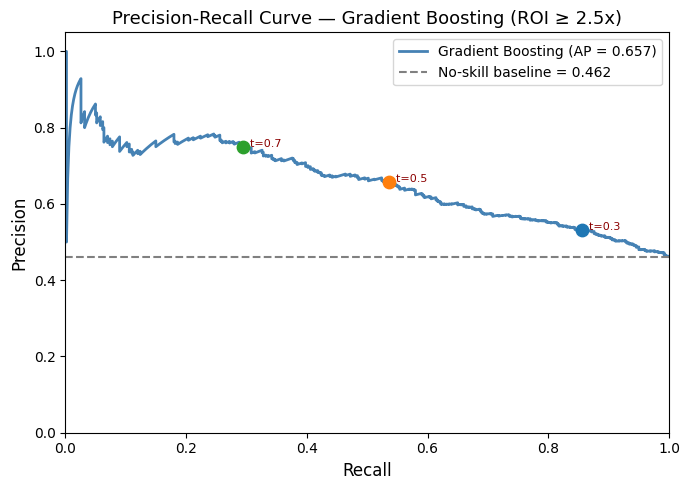

Average Precision (AP): 0.6568
No-skill baseline:      0.4621


In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, gb_prob)
avg_precision = average_precision_score(y_test, gb_prob)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', lw=2,
        label=f'Gradient Boosting (AP = {avg_precision:.3f})')
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
           label=f'No-skill baseline = {baseline:.3f}')

for thr_val in [0.3, 0.5, 0.7]:
    idx = np.argmin(np.abs(thresholds - thr_val))
    ax.scatter(recall[idx], precision[idx], s=80, zorder=5)
    ax.annotate(f'  t={thr_val}',
                xy=(recall[idx], precision[idx]),
                fontsize=8, color='darkred')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Gradient Boosting (ROI ≥ 2.5x)', fontsize=13)
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {avg_precision:.4f}')
print(f'No-skill baseline:      {baseline:.4f}')


In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for thr_val in np.arange(0.2, 0.85, 0.05):
    preds = (gb_prob >= thr_val).astype(int)
    rows.append({
        'Threshold': round(thr_val, 2),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, preds, zero_division=0), 3),
        'F1':        round(f1_score(y_test, preds, zero_division=0), 3),
    })

thr_df = pd.DataFrame(rows)
display(thr_df)


,Threshold,Precision,Recall,F1
0,0.20,0.487,0.950,0.644
1,0.25,0.503,0.918,0.650
2,0.30,0.532,0.856,0.656
3,0.35,0.562,0.756,0.645
4,0.40,0.591,0.666,0.627
5,0.45,0.626,0.592,0.608
6,0.50,0.658,0.536,0.591
7,0.55,0.677,0.470,0.555
8,0.60,0.696,0.402,0.510
9,0.65,0.718,0.342,0.463


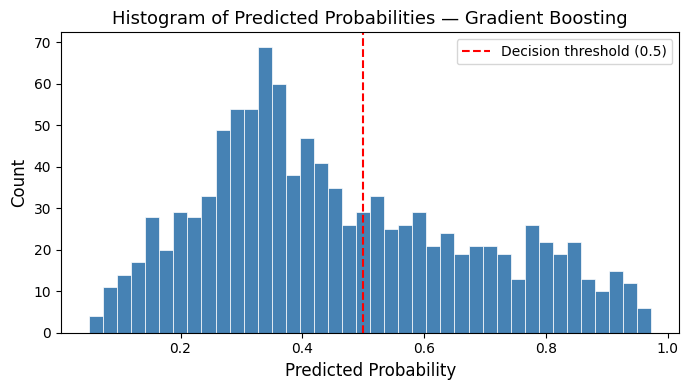

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gb_prob, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of Predicted Probabilities — Gradient Boosting', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()
